[1] 필요한 패키지 불러오기

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

[2] 퍼셉트론 클래스 선언

In [ ]:
class Perceptron():
    def __init__(self, nDim, w=[], b=0):
        self.nDim = nDim
        if len(w) > 0:
            self.w = np.array(w)
            self.b = b
        else:
            w = np.random.rand(nDim+1)
            self.w = w[1:]
            self.b = w[0]

    def printW(self):
        for i in range(self.nDim):
            print('  w{} = {:6.3f}'.format(i+1, self.w[i]), end='')
        print('  b = {:6.3f}'.format(self.b), end='')
        print()

    def predict(self, x):
        return int(np.dot(self.w, x) + self.b >= 0)

    def fit(self, X, y, N, epochs, eta=0.01):
        f = 'Epochs = {:4d}'
        print(f.format(0), end='')
        self.printW()

        for j in range(1, epochs+1):
            flag = True
            for i in range(N):
                y_hat = self.predict(X[i])
                delta = y_hat - y[i]
                if delta != 0:
                    self.w -= eta * delta * X[i]
                    self.b -= eta * delta
                    flag = False
            # 학습 과정 출력
            print(f.format(j), end='')
            self.printW()
            if flag: break

[3] 퍼셉트론 훈련을 위한 준비

In [ ]:
nSamples = 10
nDim = 2
nEpochs = 1000
eta = 0.1

[4] 학습표본

In [ ]:
# x: 입력, y: 레이블
x = np.array([[0.25, 0.75], [1.25, 1.75],
              [0.5, 0.5],   [1.75, 1.25],
              [0.75, 0.25], [1.5, 1.5],
              [0.0, 1.5],   [2.5, 0.0],
              [1.5, 0.0],   [0.0, 2.5]])
y = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

[5] 연결 가중치의 초깃값 설정

In [ ]:
w = np.array([0.1, -0.3])
b = -1

[6] 퍼셉트론 객체 생성 및 훈련

In [ ]:
p = Perceptron(nDim, w, b)
p.fit(x, y, nSamples, nEpochs, eta)

Epochs =    0  w1 =  0.100  w2 = -0.300  b = -1.000
Epochs =    1  w1 =  0.150  w2 =  0.000  b = -0.600
Epochs =    2  w1 =  0.025  w2 = -0.075  b = -0.400
Epochs =    3  w1 =  0.150  w2 = -0.150  b = -0.100
Epochs =    4  w1 =  0.000  w2 = -0.050  b =  0.100
Epochs =    5  w1 = -0.100  w2 = -0.250  b =  0.200
Epochs =    6  w1 = -0.175  w2 = -0.175  b =  0.300
Epochs =    7  w1 = -0.175  w2 = -0.175  b =  0.300


[7] 시각화를 위한 격자 좌표 구성

In [ ]:
# -1 <= x1, x2 <= 3 범위의 격자 좌표 생성
nGrid = 81    # 한 축의격자의 수
x1_lin = np.linspace(-1, 3, nGrid)
x2_lin = np.linspace(-1, 3, nGrid)

# nGrid x nGrid개의 격자좌표의 x1, x2 값
x1_mesh, x2_mesh = np.meshgrid(x1_lin, x2_lin)

# Perceptron의 입력 구성: (x1, x2) 좌표의 배열
xx = np.vstack([x1_mesh.ravel(), x2_mesh.ravel()]).T

[8] 학습된 퍼셉트론으로 격자 좌표에 대한 출력 계산

In [ ]:
yy = np.empty(nGrid*nGrid, dtype=int)
for k in range(nGrid*nGrid):
    yy[k] = p.predict(xx[k])

[9] 학습 결과의 시각화

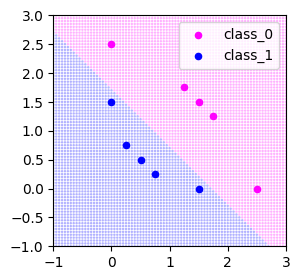

In [ ]:
plt.rcParams["figure.figsize"] = (3, 3)
plt.ylim(-1, 3)
plt.xlim(-1, 3)

colors = ['magenta', 'blue']
class_id = ['class_0', 'class_1']

# 클래스별로 산점도 그리기
for i, col, c_name in zip([0, 1], colors, class_id):
    plt.scatter(xx[yy == i, 0], xx[yy == i, 1],
                c = col, s = 3, alpha = 0.3,
                edgecolors = 'none')
    plt.scatter(x[y == i, 0], x[y == i, 1],
                c = col, s = 20, label=c_name)

# 범례가 우상단에 위치하게 지정한 후 그래프 출력
plt.legend(loc='upper right')
plt.show()